In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pickle

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BHATTI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
nltk.download('punkt', download_dir='nltk_data')
import os
nltk.data.path.append(os.path.abspath("nltk_data"))

[nltk_data] Downloading package punkt to nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
from nltk.tokenize import word_tokenize, sent_tokenize

In [5]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\BHATTI\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
Unnamed = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
df = df.drop(columns = Unnamed)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [12]:
le = LabelEncoder()
df['v1'] = le.fit_transform(df['v1'])

In [13]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df= df.drop_duplicates()

In [16]:
df.shape

(5169, 2)

In [17]:
df['chars'] = df['v2'].apply(len)

In [18]:
df['words'] = df['v2'].apply(lambda x: len(word_tokenize(x)))

In [19]:
df['sents'] = df['v2'].apply(lambda x: len(sent_tokenize(x)))

In [20]:
df.head()

,v1,v2,chars,words,sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [21]:
df[df['v1'] == 0][['chars', 'words', 'sents']].describe()

,chars,words,sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [22]:
df[df['v1'] == 1][['chars', 'words', 'sents']].describe()

,chars,words,sents
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


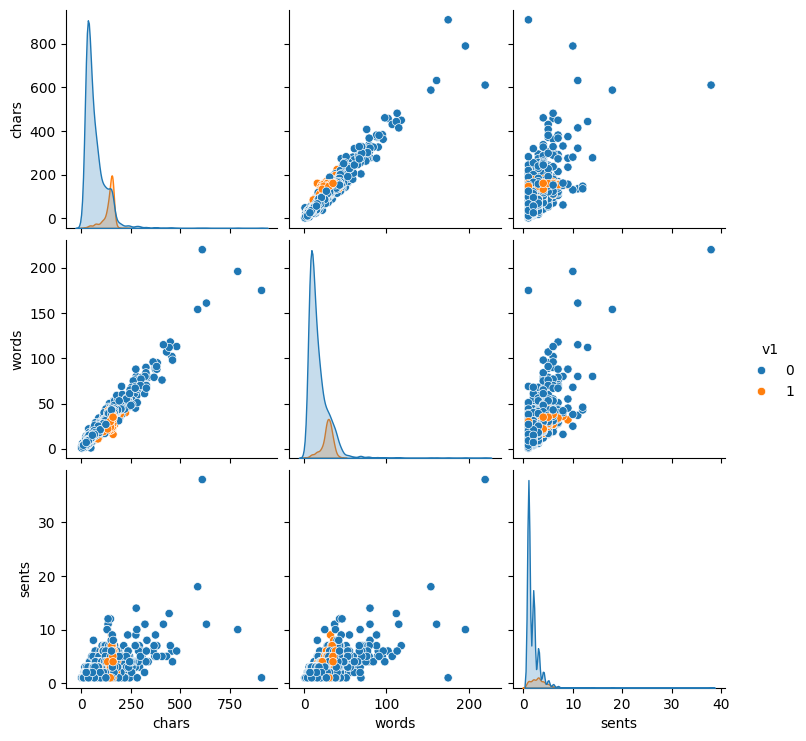

In [23]:
import seaborn as sns
sns.pairplot(df, hue='v1')

In [24]:
df.drop(columns=['v2']).corr()


,v1,chars,words,sents
v1,1.000000,0.384717,0.262912,0.263939
chars,0.384717,1.000000,0.965760,0.624139
words,0.262912,0.965760,1.000000,0.679971
sents,0.263939,0.624139,0.679971,1.000000


In [25]:
df.head()

,v1,v2,chars,words,sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
ps = PorterStemmer()

In [27]:
def transformText(text):
    if text is None:
        return ""

    text = str(text).lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [28]:
df['Text'] = df['v2'].apply(transformText)

In [29]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['v1'] == 1]['Text'].str.cat(sep=" "))

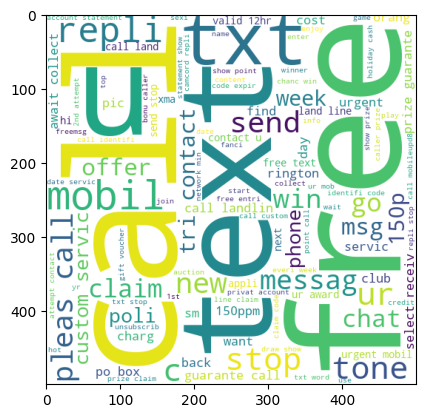

In [30]:
plt.Figure(figsize=(15,8))
plt.imshow(spam_wc)

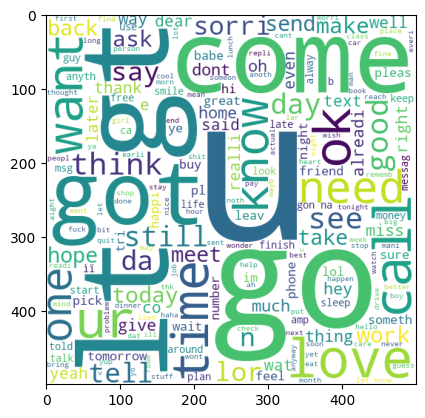

In [31]:
ham_wc = wc.generate(df[df['v1'] == 0]['Text'].str.cat(sep=" "))
plt.Figure(figsize=(15,8))
plt.imshow(ham_wc)

In [32]:
spam_corpus = []
for msg in df[df['v1'] == 1]['Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [33]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

<Axes: ylabel='1'>

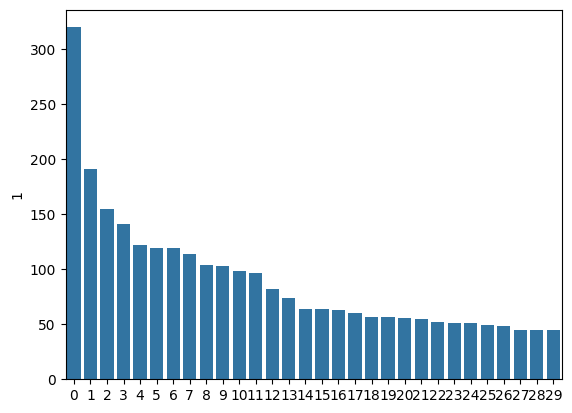

In [34]:
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])

In [35]:
ham_corpus = []
for msg in df[df['v1'] == 1]['Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [36]:
ham_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

<Axes: ylabel='0'>

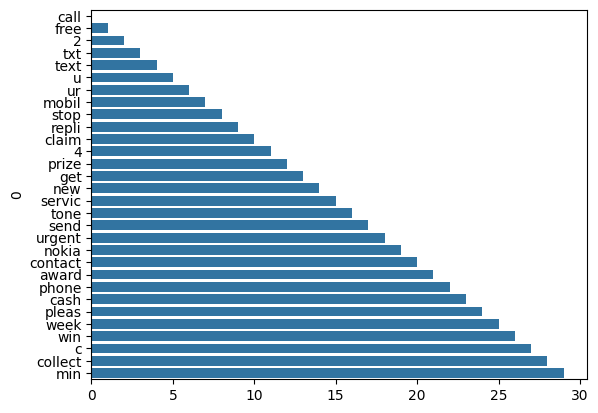

In [37]:
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0])

In [38]:
cv = CountVectorizer()
X = cv.fit_transform(df['Text']).toarray()

In [39]:
X.shape

(5169, 6708)

In [40]:
y = df['v1'].values

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
knn = KNeighborsClassifier(n_neighbors=5)
svc = SVC(kernel = 'rbf')
lsvc = LinearSVC(class_weight='balanced')
lr = LogisticRegression(class_weight='balanced')
rft = RandomForestClassifier(n_estimators=100)


In [43]:
nb = [gnb, mnb, bnb, knn, svc, lsvc, lr, rft]
for model in nb:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("The accuracy for model : ", str(model), "is: ", accuracy_score(y_test, y_pred))
    print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
    print("precession Score: ", precision_score(y_test, y_pred))


print("Cross Validation Scores:")
for model in nb:
    score = cross_val_score(model, X_train, y_train, cv=5, scoring = 'accuracy')
    print("The accuracy for model : ", str(model), "is: ", score.mean())




The accuracy for model :  GaussianNB() is:  0.8684719535783365
Confusion Matrix: 
 [[772 117]
 [ 19 126]]
precession Score:  0.5185185185185185
The accuracy for model :  MultinomialNB() is:  0.9738878143133463
Confusion Matrix: 
 [[872  17]
 [ 10 135]]
precession Score:  0.8881578947368421
The accuracy for model :  BernoulliNB() is:  0.9661508704061895
Confusion Matrix: 
 [[885   4]
 [ 31 114]]
precession Score:  0.9661016949152542
The accuracy for model :  KNeighborsClassifier() is:  0.9042553191489362
Confusion Matrix: 
 [[889   0]
 [ 99  46]]
precession Score:  1.0
The accuracy for model :  SVC() is:  0.9709864603481625
Confusion Matrix: 
 [[887   2]
 [ 28 117]]
precession Score:  0.9831932773109243
The accuracy for model :  LinearSVC(class_weight='balanced') is:  0.9816247582205029
Confusion Matrix: 
 [[886   3]
 [ 16 129]]
precession Score:  0.9772727272727273
The accuracy for model :  LogisticRegression(class_weight='balanced') is:  0.9777562862669246
Confusion Matrix: 
 [[881   

In [70]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['Text']).toarray()
y = df['v1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
nb = [gnb, mnb, bnb, knn, svc, lsvc, lr, rft]
for model in nb:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("The accuracy for model : ", str(model), "is: ", accuracy_score(y_test, y_pred))
    print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
    print("precession Score: ", precision_score(y_test, y_pred))


print("Cross Validation Scores:")
for model in nb:
    score = cross_val_score(model, X_train, y_train, cv=5, scoring = 'accuracy')
    print("The accuracy for model : ", str(model), "is: ", score.mean())




The accuracy for model :  GaussianNB() is:  0.8626692456479691
Confusion Matrix: 
 [[771 118]
 [ 24 121]]
precession Score:  0.5062761506276151
The accuracy for model :  MultinomialNB() is:  0.9729206963249516
Confusion Matrix: 
 [[888   1]
 [ 27 118]]
precession Score:  0.9915966386554622
The accuracy for model :  BernoulliNB() is:  0.9729206963249516
Confusion Matrix: 
 [[884   5]
 [ 23 122]]
precession Score:  0.9606299212598425
The accuracy for model :  KNeighborsClassifier() is:  0.9148936170212766
Confusion Matrix: 
 [[889   0]
 [ 88  57]]
precession Score:  1.0
The accuracy for model :  SVC() is:  0.9748549323017408
Confusion Matrix: 
 [[888   1]
 [ 25 120]]
precession Score:  0.9917355371900827
The accuracy for model :  LinearSVC(class_weight='balanced') is:  0.9758220502901354
Confusion Matrix: 
 [[876  13]
 [ 12 133]]
precession Score:  0.910958904109589
The accuracy for model :  LogisticRegression(class_weight='balanced') is:  0.9671179883945842
Confusion Matrix: 
 [[868  21

In [73]:
#Choosing tfidf --> MultinomialNB
mnb = MultinomialNB() 
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print("The accuracy for mnb is: ", accuracy_score(y_test, y_pred))
print("Confusion Matrix for mnb is: \n", confusion_matrix(y_test, y_pred))
print("precession Score for mnb is: ", precision_score(y_test, y_pred))


print("Cross Validation Scores:")
score = cross_val_score(mnb, X_train, y_train, cv=5, scoring = 'accuracy')
print("The accuracy for mnb is: ", score.mean())


TypeError: MultinomialNB.__init__() got an unexpected keyword argument 'max_features'

The accuracy for knn is:  0.8965183752417795
Confusion Matrix for knn is: 
 [[889   0]
 [107  38]]
precession Score for knn is:  1.0
Cross Validation Scores:
The accuracy for knn is:  0.8967351874244256


In [50]:
pickle.dump(tfidf, open('Vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('MultinomialNB.pkl', 'wb'))

In [53]:
text = "SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info"

cleaned = transformText(text)
print(cleaned)

six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info


In [69]:
model = pickle.load(open('MultinomialNB.pkl', 'rb'))   # or your classifier file
vectorizer = pickle.load(open('Vectorizer.pkl', 'rb')) # tfidf/count vectorizer used at training

def spammed(text):
    # preprocess
    text_cleaned = transformText(text)
    # ensure vectorizer sees it as 1 document
    X_text = vectorizer.transform([text_cleaned])
    # numeric column: message length (same as in training)
    X_num = sparse.csr_matrix([[len(text)]])
    # combine features
    X_final = sparse.hstack([X_text, X_num])
    return X_final

# Example usage
msg = "Congratulations! You have won a free iPhone, click here now."
X = spammed(msg)

print("Model expects:", model.n_features_in_)
print("X shape:", X.shape)

pred = model.predict(X)[0]
label_map = {0: "Not Spam", 1: "Spam"}
print("Prediction:", label_map[int(pred)])


Model expects: 6709
X shape: (1, 6709)
Prediction: Not Spam


ValueError: X has 6708 features, but RandomForestClassifier is expecting 3000 features as input.